# Análise exploratória — Rio Grande do Sul (safra 2026-06)

Recorte de `analise_exploratoria.ipynb` para **UF = RS**.
Nota de modelagem: UF é atributo do **estabelecimento**; nas análises de
empresa (porte, Simples/MEI) o recorte usa empresas com **matriz no RS**.

In [1]:
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

con = duckdb.connect(str(Path("..") / "rfb.duckdb"), read_only=True)
con.execute("SET memory_limit='12GB'")
con.execute("SET threads=4")

AZUL, AQUA, VERMELHO = "#2a78d6", "#1baf7a", "#e34948"
INK, INK_2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.labelcolor": INK_2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": INK, "font.size": 10.5, "font.family": "sans-serif",
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "figure.dpi": 110,
})


def eixo_limpo(ax, x=False):
    ax.grid(axis="x" if x else "y")
    ax.grid(False, axis="y" if x else "x")
    return ax


def fmt_mil(v, _):
    return f"{v/1e6:.1f}M" if v >= 1e6 else (f"{v/1e3:.0f}k" if v >= 1e3 else f"{v:.0f}")


## 1. RS no contexto nacional

In [2]:
resumo = con.sql("""
    SELECT
        count(*)                                   AS estabelecimentos,
        count(*) FILTER (situacao = 'ativa')       AS ativos,
        count(*) FILTER (situacao = 'baixada')     AS baixados,
        count(DISTINCT cnpj_basico)                AS empresas_distintas,
        count(DISTINCT municipio)                  AS municipios
    FROM estabelecimentos_completos WHERE uf = 'RS'
""").df()

brasil = con.sql("""
    SELECT count(*) AS total, count(*) FILTER (situacao = 'ativa') AS ativos
    FROM estabelecimentos_completos
""").df()

r, b = resumo.iloc[0], brasil.iloc[0]
print(f"Estabelecimentos RS:  {r.estabelecimentos:>12,} ({r.estabelecimentos/b.total:.1%} do Brasil)")
print(f"Ativos RS:            {r.ativos:>12,} ({r.ativos/b.ativos:.1%} dos ativos do Brasil)")
print(f"Taxa de atividade RS: {r.ativos/r.estabelecimentos:>11.1%}  (Brasil: {b.ativos/b.total:.1%})")
print(f"Empresas distintas:   {r.empresas_distintas:>12,}")
print(f"Municípios com CNPJ:  {r.municipios:>12,}")

Estabelecimentos RS:     4,906,003 (6.8% do Brasil)
Ativos RS:               1,760,961 (6.3% dos ativos do Brasil)
Taxa de atividade RS:       35.9%  (Brasil: 39.1%)
Empresas distintas:      4,680,558
Municípios com CNPJ:           497


## 2. Situação cadastral no RS

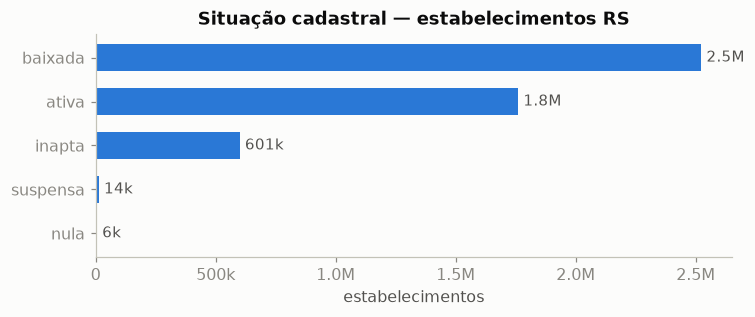

In [3]:
sit = con.sql("""
    SELECT COALESCE(situacao, 'sem informacao') AS situacao, count(*) AS n
    FROM estabelecimentos_completos WHERE uf = 'RS'
    GROUP BY 1 ORDER BY n DESC
""").df()

fig, ax = plt.subplots(figsize=(7, 3))
barras = ax.barh(sit["situacao"], sit["n"], color=AZUL, height=0.62)
ax.invert_yaxis(); eixo_limpo(ax, x=True)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(fmt_mil))
for b_, v in zip(barras, sit["n"]):
    ax.text(v, b_.get_y() + b_.get_height()/2, f" {fmt_mil(v, None)}",
            va="center", fontsize=10, color=INK_2)
ax.set_title("Situação cadastral — estabelecimentos RS")
ax.set_xlabel("estabelecimentos")
plt.tight_layout(); plt.show()

## 3. Top 15 municípios em estabelecimentos ativos

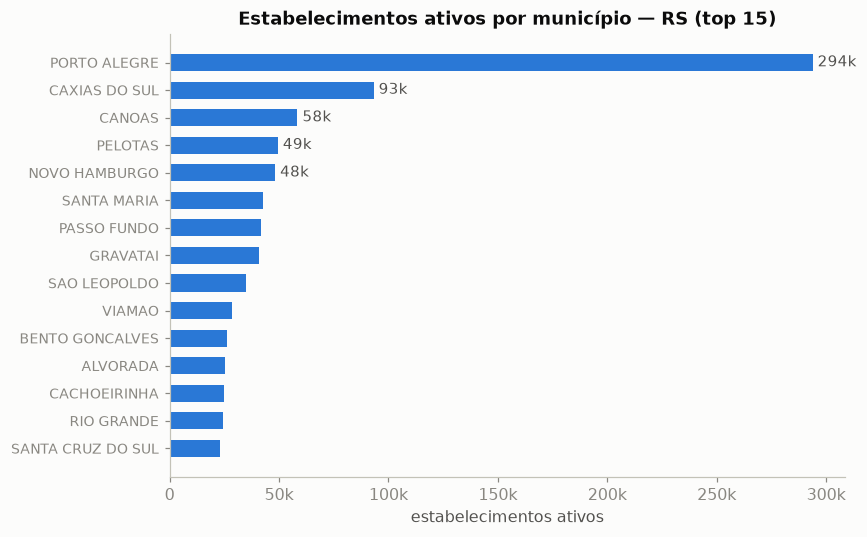

Porto Alegre: 16.7% dos ativos do RS


In [4]:
mun = con.sql("""
    SELECT municipio, count(*) AS n
    FROM estabelecimentos_completos
    WHERE uf = 'RS' AND situacao = 'ativa'
    GROUP BY municipio ORDER BY n DESC LIMIT 15
""").df()

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.barh(mun["municipio"], mun["n"], color=AZUL, height=0.62)
ax.invert_yaxis(); eixo_limpo(ax, x=True)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(fmt_mil))
for b_, v in zip(barras[:5], mun["n"][:5]):
    ax.text(v, b_.get_y() + b_.get_height()/2, f" {fmt_mil(v, None)}",
            va="center", fontsize=9.5, color=INK_2)
ax.set_title("Estabelecimentos ativos por município — RS (top 15)")
ax.set_xlabel("estabelecimentos ativos")
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout(); plt.show()

total_rs = con.sql("SELECT count(*) FROM estabelecimentos_completos WHERE uf='RS' AND situacao='ativa'").fetchone()[0]
print(f"Porto Alegre: {mun.n.iloc[0]/total_rs:.1%} dos ativos do RS")

## 4. Top 15 CNAEs entre ativos no RS

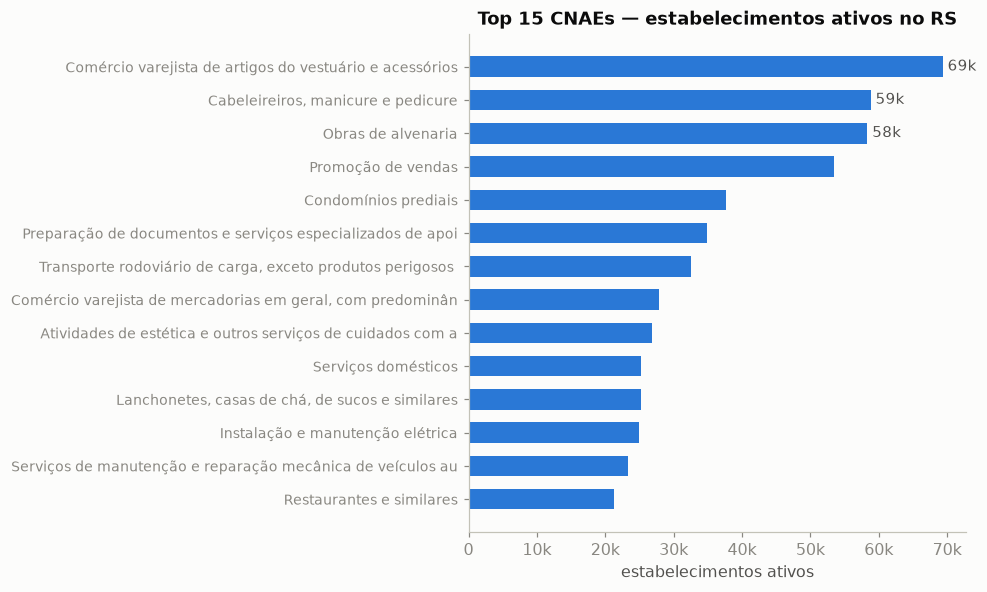

In [5]:
cnae = con.sql("""
    SELECT cnae_principal, count(*) AS n
    FROM estabelecimentos_completos
    WHERE uf = 'RS' AND situacao = 'ativa' AND cnae_principal IS NOT NULL
    GROUP BY 1 ORDER BY n DESC LIMIT 15
""").df()
cnae["rotulo"] = cnae["cnae_principal"].str.slice(0, 58)

fig, ax = plt.subplots(figsize=(9, 5.5))
barras = ax.barh(cnae["rotulo"], cnae["n"], color=AZUL, height=0.62)
ax.invert_yaxis(); eixo_limpo(ax, x=True)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(fmt_mil))
for b_, v in zip(barras[:3], cnae["n"][:3]):
    ax.text(v, b_.get_y() + b_.get_height()/2, f" {fmt_mil(v, None)}",
            va="center", fontsize=9.5, color=INK_2)
ax.set_title("Top 15 CNAEs — estabelecimentos ativos no RS")
ax.set_xlabel("estabelecimentos ativos")
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout(); plt.show()

## 5. Aberturas por ano — RS × participação no Brasil

Linha do RS e, em gráfico separado (escala própria, nunca eixo duplo),
a fatia do RS no total nacional de aberturas de cada ano.

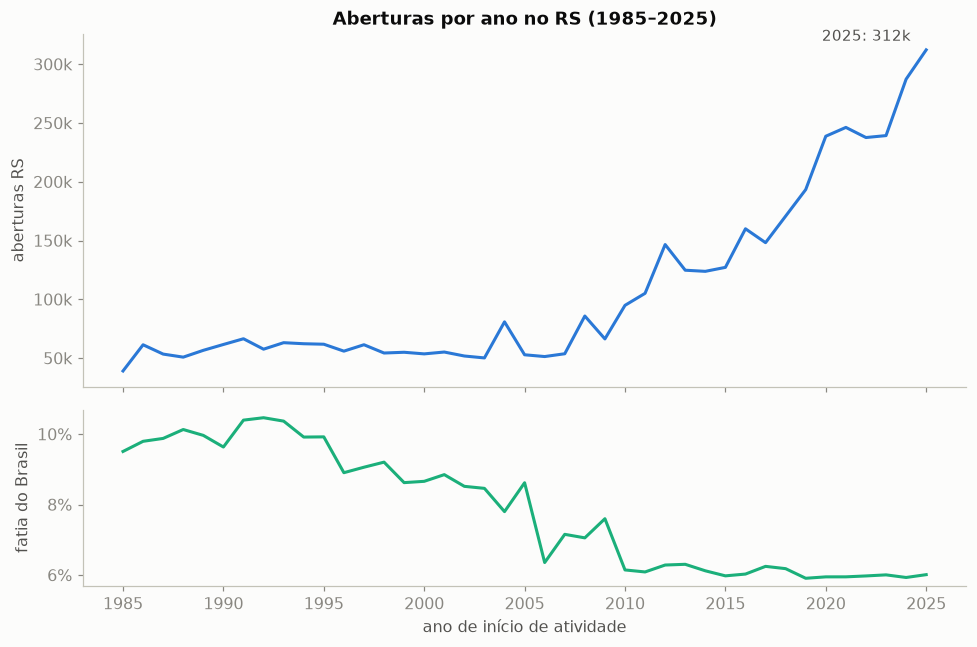

In [6]:
abert = con.sql("""
    WITH base AS (
        SELECT CAST(substr(e.data_inicio_atividade, 1, 4) AS INT) AS ano,
               count(*) AS brasil,
               count(*) FILTER (e.uf = 'RS') AS rs
        FROM estabelecimentos e
        WHERE length(e.data_inicio_atividade) = 8
          AND substr(e.data_inicio_atividade, 1, 4) BETWEEN '1985' AND '2025'
        GROUP BY 1
    )
    SELECT ano, rs, brasil, rs * 100.0 / brasil AS fatia_pct FROM base ORDER BY ano
""").df()

fig, (a1, a2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]})
a1.plot(abert["ano"], abert["rs"], color=AZUL, linewidth=2)
eixo_limpo(a1)
a1.yaxis.set_major_formatter(mtick.FuncFormatter(fmt_mil))
pico = abert.loc[abert.rs.idxmax()]
a1.annotate(f"{int(pico.ano)}: {fmt_mil(pico.rs, None)}", (pico.ano, pico.rs),
            textcoords="offset points", xytext=(-10, 6), ha="right",
            fontsize=10, color=INK_2)
a1.set_title("Aberturas por ano no RS (1985–2025)")
a1.set_ylabel("aberturas RS")

a2.plot(abert["ano"], abert["fatia_pct"], color=AQUA, linewidth=2)
eixo_limpo(a2)
a2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:.0f}%"))
a2.set_ylabel("fatia do Brasil")
a2.set_xlabel("ano de início de atividade")
plt.tight_layout(); plt.show()

## 6. Porte e regime tributário — empresas com matriz no RS

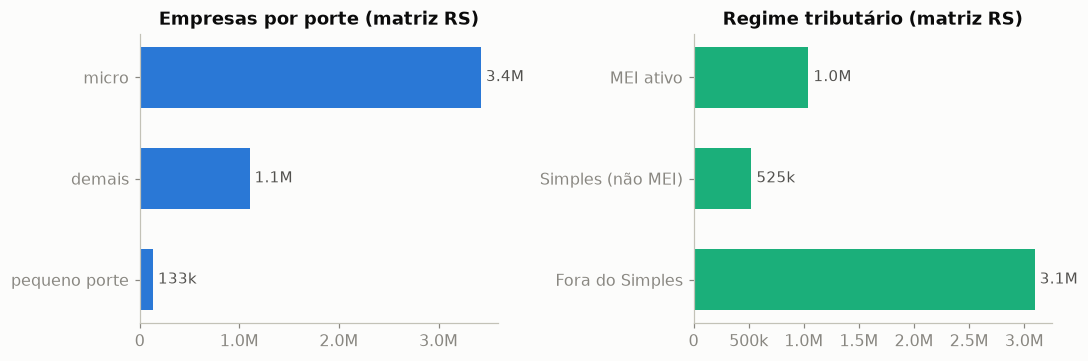

In [7]:
matriz_rs = """
    SELECT DISTINCT cnpj_basico FROM estabelecimentos_completos
    WHERE uf = 'RS' AND matriz_filial = 'matriz'
"""

porte = con.sql(f"""
    SELECT COALESCE(ec.porte, 'sem informacao') AS porte, count(*) AS n
    FROM empresas_completas ec
    SEMI JOIN ({matriz_rs}) m ON ec.cnpj_basico = m.cnpj_basico
    GROUP BY 1 ORDER BY n DESC
""").df()

regime = con.sql(f"""
    SELECT
        count(*) FILTER (opcao_mei = 'S') AS "MEI ativo",
        count(*) FILTER (opcao_simples = 'S' AND (opcao_mei IS NULL OR opcao_mei <> 'S')) AS "Simples (não MEI)",
        count(*) FILTER (COALESCE(opcao_simples,'N') <> 'S' AND COALESCE(opcao_mei,'N') <> 'S') AS "Fora do Simples"
    FROM empresas_completas ec
    SEMI JOIN ({matriz_rs}) m ON ec.cnpj_basico = m.cnpj_basico
""").df().T.reset_index()
regime.columns = ["regime", "n"]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.4))
b1 = a1.barh(porte["porte"], porte["n"], color=AZUL, height=0.6)
a1.invert_yaxis(); eixo_limpo(a1, x=True)
a1.xaxis.set_major_formatter(mtick.FuncFormatter(fmt_mil))
for b_, v in zip(b1, porte["n"]):
    a1.text(v, b_.get_y() + b_.get_height()/2, f" {fmt_mil(v, None)}",
            va="center", fontsize=9.5, color=INK_2)
a1.set_title("Empresas por porte (matriz RS)")

b2 = a2.barh(regime["regime"], regime["n"], color=AQUA, height=0.6)
a2.invert_yaxis(); eixo_limpo(a2, x=True)
a2.xaxis.set_major_formatter(mtick.FuncFormatter(fmt_mil))
for b_, v in zip(b2, regime["n"]):
    a2.text(v, b_.get_y() + b_.get_height()/2, f" {fmt_mil(v, None)}",
            va="center", fontsize=9.5, color=INK_2)
a2.set_title("Regime tributário (matriz RS)")
plt.tight_layout(); plt.show()

## 7. Sobrevivência: idade dos estabelecimentos na baixa

Para estabelecimentos baixados no RS: quantos anos viveram entre a abertura
(`data_inicio_atividade`) e a baixa (`data_situacao_cadastral`).

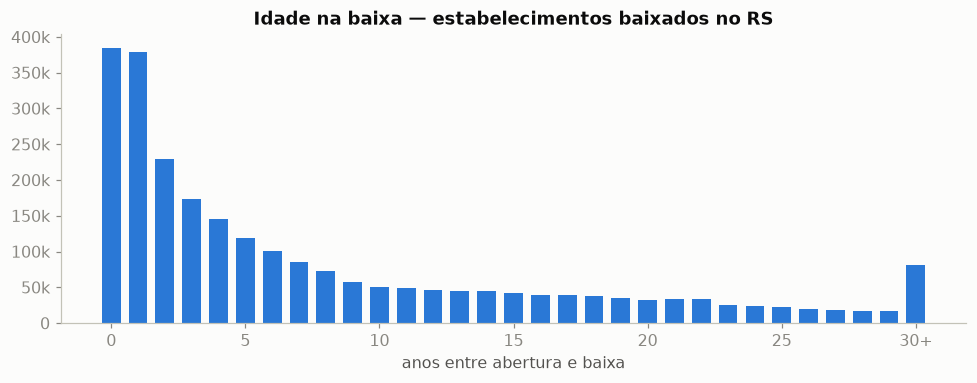

Baixados com até 5 anos:  57.2%
Baixados com até 10 anos: 71.9%


In [8]:
vida = con.sql("""
    SELECT
        least(floor(datediff('year',
            strptime(data_inicio_atividade, '%Y%m%d'),
            strptime(data_situacao_cadastral, '%Y%m%d'))), 30) AS anos,
        count(*) AS n
    FROM estabelecimentos_completos
    WHERE uf = 'RS' AND situacao = 'baixada'
      AND length(data_inicio_atividade) = 8 AND data_inicio_atividade > '19000101'
      AND length(data_situacao_cadastral) = 8 AND data_situacao_cadastral > data_inicio_atividade
    GROUP BY 1 HAVING anos >= 0 ORDER BY 1
""").df()

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.bar(vida["anos"], vida["n"], color=AZUL, width=0.7)
eixo_limpo(ax)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(fmt_mil))
ax.set_xticks(range(0, 31, 5))
ax.set_xticklabels(["0", "5", "10", "15", "20", "25", "30+"])
ax.set_title("Idade na baixa — estabelecimentos baixados no RS")
ax.set_xlabel("anos entre abertura e baixa")
plt.tight_layout(); plt.show()

acum = vida.set_index("anos")["n"]
print(f"Baixados com até 5 anos:  {acum.loc[:5].sum() / acum.sum():.1%}")
print(f"Baixados com até 10 anos: {acum.loc[:10].sum() / acum.sum():.1%}")

## 8. Longevidade dos estabelecimentos ativos

Espelho da análise de sobrevivência: idade **dos que estão vivos** (anos entre
a abertura e a referência da safra, 2026-06-30).

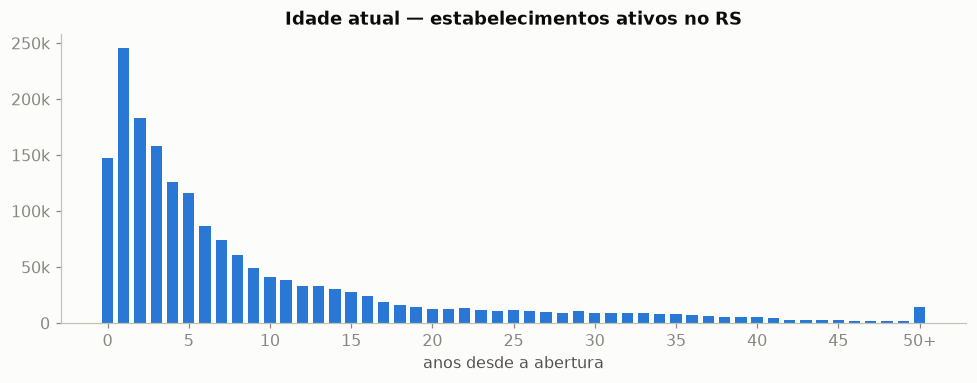

Idade mediana das ativas: 5.0 anos
Ativas com ate 5 anos:    55.5%
Ativas com 20+ anos:      13.3%


In [9]:
longev = con.sql("""
    SELECT least(floor(datediff('year',
               strptime(data_inicio_atividade, '%Y%m%d'),
               DATE '2026-06-30')), 50) AS anos,
           count(*) AS n
    FROM estabelecimentos_completos
    WHERE uf = 'RS' AND situacao = 'ativa'
      AND length(data_inicio_atividade) = 8 AND data_inicio_atividade > '19000101'
    GROUP BY 1 HAVING anos >= 0 ORDER BY 1
""").df()

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.bar(longev["anos"], longev["n"], color=AZUL, width=0.7)
eixo_limpo(ax)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(fmt_mil))
ax.set_xticks(range(0, 51, 5))
ax.set_xticklabels([str(x) for x in range(0, 50, 5)] + ["50+"])
ax.set_title("Idade atual — estabelecimentos ativos no RS")
ax.set_xlabel("anos desde a abertura")
plt.tight_layout(); plt.show()

acum = longev.set_index("anos")["n"]
total = acum.sum()
mediana = (acum.cumsum() >= total / 2).idxmax()
print(f"Idade mediana das ativas: {mediana} anos")
print(f"Ativas com ate 5 anos:    {acum.loc[:5].sum() / total:.1%}")
print(f"Ativas com 20+ anos:      {acum.loc[20:].sum() / total:.1%}")

## 9. Análise por região geográfica intermediária (IBGE)

Divisão oficial do IBGE vigente desde 2017 (substitui as mesorregiões): o RS
tem **8 regiões intermediárias**. Mapeamento município→região em
`apoio/ibge_regioes_rs.csv` (gerado da API de localidades do IBGE; join por
nome normalizado — 497/497 municípios casam). O CSV também traz região
imediata e mesorregião pra recortes mais finos.

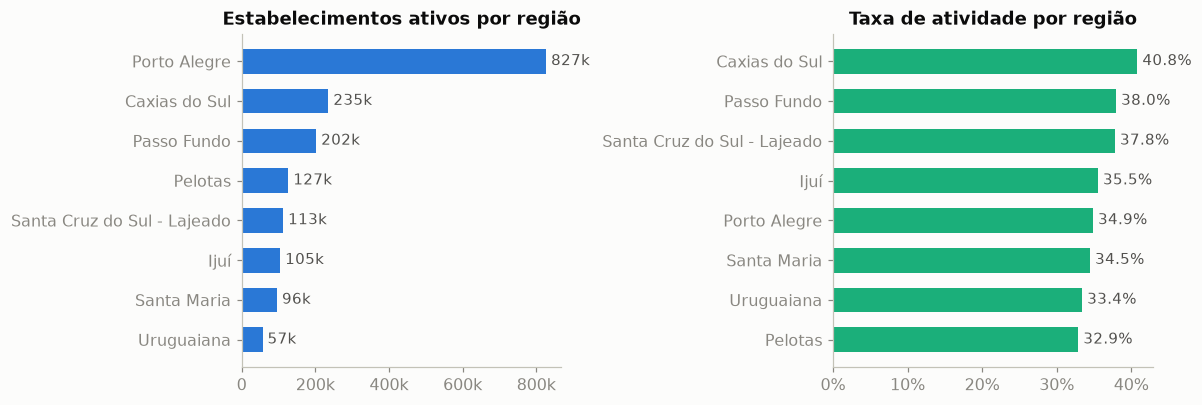

,regiao_intermediaria,estabelecimentos,ativos,municipios,taxa_atividade
0,Porto Alegre,"2,371,186","826,754",90,34.9%
1,Caxias do Sul,"576,878","235,478",54,40.8%
2,Passo Fundo,"533,201","202,428",144,38.0%
3,Pelotas,"384,958","126,626",24,32.9%
4,Santa Cruz do Sul - Lajeado,"297,789","112,584",58,37.8%
5,Ijuí,"294,223","104,526",77,35.5%
6,Santa Maria,"278,321","95,942",40,34.5%
7,Uruguaiana,"169,447","56,623",10,33.4%


In [10]:
con.execute("""
    CREATE OR REPLACE TEMP VIEW rs_regioes AS
    WITH mapa AS (
        SELECT municipio_norm, regiao_intermediaria
        FROM read_csv('apoio/ibge_regioes_rs.csv', header=true)
    )
    SELECT ec.*, mapa.regiao_intermediaria
    FROM estabelecimentos_completos ec
    JOIN mapa ON regexp_replace(
                     replace(replace(strip_accents(upper(ec.municipio)), '''', ''), '-', ' '),
                     ' +', ' ', 'g') = mapa.municipio_norm
    WHERE ec.uf = 'RS'
""")

reg = con.sql("""
    SELECT regiao_intermediaria,
           count(*)                              AS estabelecimentos,
           count(*) FILTER (situacao = 'ativa')  AS ativos,
           count(DISTINCT municipio)             AS municipios
    FROM rs_regioes
    GROUP BY 1 ORDER BY ativos DESC
""").df()
reg["taxa_atividade"] = reg.ativos / reg.estabelecimentos

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
b1 = a1.barh(reg["regiao_intermediaria"], reg["ativos"], color=AZUL, height=0.62)
a1.invert_yaxis(); eixo_limpo(a1, x=True)
a1.xaxis.set_major_formatter(mtick.FuncFormatter(fmt_mil))
for b_, v in zip(b1, reg["ativos"]):
    a1.text(v, b_.get_y() + b_.get_height()/2, f" {fmt_mil(v, None)}",
            va="center", fontsize=9.5, color=INK_2)
a1.set_title("Estabelecimentos ativos por região")

ordem = reg.sort_values("taxa_atividade", ascending=False)
b2 = a2.barh(ordem["regiao_intermediaria"], ordem["taxa_atividade"] * 100, color=AQUA, height=0.62)
a2.invert_yaxis(); eixo_limpo(a2, x=True)
a2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:.0f}%"))
for b_, v in zip(b2, ordem["taxa_atividade"]):
    a2.text(v * 100, b_.get_y() + b_.get_height()/2, f" {v:.1%}",
            va="center", fontsize=9.5, color=INK_2)
a2.set_title("Taxa de atividade por região")
plt.tight_layout(); plt.show()

tab = reg.copy()
tab["ativos"] = tab["ativos"].map("{:,.0f}".format)
tab["estabelecimentos"] = tab["estabelecimentos"].map("{:,.0f}".format)
tab["taxa_atividade"] = tab["taxa_atividade"].map("{:.1%}".format)
tab

In [11]:
top_mun = con.sql("""
    SELECT regiao_intermediaria, municipio, count(*) AS ativos,
           row_number() OVER (PARTITION BY regiao_intermediaria ORDER BY count(*) DESC) AS rk
    FROM rs_regioes WHERE situacao = 'ativa'
    GROUP BY 1, 2 QUALIFY rk <= 3 ORDER BY regiao_intermediaria, rk
""").df()
top_mun["ativos"] = top_mun["ativos"].map("{:,.0f}".format)
top_mun.drop(columns="rk")

,regiao_intermediaria,municipio,ativos
0,Caxias do Sul,CAXIAS DO SUL,"93,242"
1,Caxias do Sul,BENTO GONCALVES,"26,362"
2,Caxias do Sul,GRAMADO,"12,452"
3,Ijuí,IJUI,"14,907"
4,Ijuí,SANTA ROSA,"12,316"
5,Ijuí,SANTO ANGELO,"11,720"
6,Passo Fundo,PASSO FUNDO,"41,741"
7,Passo Fundo,ERECHIM,"22,055"
8,Passo Fundo,CARAZINHO,"9,822"
9,Pelotas,PELOTAS,"49,458"


## 10. Síntese — RS

- RS tem **4,9M de estabelecimentos** (6,8% do Brasil), **1,76M ativos** (6,3% dos ativos nacionais).
- **Taxa de atividade menor que a nacional**: 35,9% vs 39,1%.
- **Porto Alegre (município) concentra 16,7%** dos ativos; o interior pesa mais que no padrão nacional.
- Top de CNAEs segue o padrão nacional MEI-heavy (varejo de vestuário, cabeleireiros, obras).
- A fatia do RS nas aberturas nacionais **cai ao longo do tempo** — o estado formaliza menos que o Brasil cresce.
- **Mortalidade precoce**: 57,2% dos baixados não passaram de 5 anos; 71,9% não passaram de 10.
- **Base ativa também é jovem**: idade mediana de 5 anos; 55,5% das ativas têm ≤5 anos e só 13,3% têm 20+ — o estoque renova rápido dos dois lados (muita entrada recente, muita saída precoce).
- **Por região intermediária (IBGE)**: a região de Porto Alegre domina em volume (827k ativos, ~47% do RS em 90 municípios), mas **Caxias do Sul tem a maior taxa de atividade (40,8%)** — única acima da média nacional. Pelotas tem a menor (32,9%). Passo Fundo é a mais pulverizada: 144 municípios.

Próximos recortes: comparação RS × SC × PR (Sul), sobrevivência por CNAE,
regiões imediatas/mesorregiões (já no CSV de apoio), evolução multi-safra.